**Не зафиксировал объективно, повлияля ли видеокарта на скорость обчения. Поэтому лучше перед выполнением ячеек всё же переключиться на графический процессор.**

# **Практическое занятие: RNN, LSTM и GRU**

В этом блокноте мы проведём эксперименты с рекуррентными сетями, чтобы на практике увидеть, как они справляются с долгосрочными зависимостями и как LSTM/GRU решают проблему затухающих градиентов. Мы используем PyTorch и Google Colab.

**План практики:**
1. **Adding problem** – синтетическая задача, требующая запоминания информации на большом расстоянии. Сравним vanilla RNN, LSTM и GRU, визуализируем градиенты.
2. **Классификация тональности на русском языке** – используем датасет RuSentiment, построим BiLSTM, сравним однонаправленную и двунаправленную модели, визуализируем скрытые состояния через t-SNE.

👉 *Инструкция:* Запускайте ячейки последовательно, меняйте гиперпараметры, где предложено, и отвечайте на вопросы для интерпретации.

## **1. Установка и импорт библиотек**

In [ ]:
%pip install -q datasets transformers scikit-learn matplotlib seaborn

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from tqdm import tqdm
import random
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## **2. Эксперимент 1: Adding problem (задача на долгосрочные зависимости)**

**Описание задачи:** Даётся последовательность случайных чисел $x_1, \dots, x_T$ (обычно T=100) и два индекса $i$ и $j$ (первый в первой половине, второй – во второй). Цель – рассчитать сумму $x_i + x_j$. Модель должна запомнить значения на больших расстояниях.

Мы сравним три модели: **vanilla RNN**, **LSTM**, **GRU**. Будем отслеживать:
- потери на валидации
- нормы градиентов для разных шагов времени (чтобы увидеть затухание)

Здесь формируются numpy вектора на выходе.

In [2]:
def generate_adding_problem_data(num_samples, seq_len=100):
    """
    Генерирует синтетический датасет для adding problem.
    Возвращает: X (num_samples, seq_len, 2) – два канала: значение и индикатор позиции,
                y (num_samples) – сумма двух выбранных чисел.
    """
    X = np.random.uniform(0, 1, (num_samples, seq_len, 2)).astype(np.float32)
    y = np.zeros((num_samples,), dtype=np.float32)
    for i in range(num_samples):
        # выбираем случайные индексы: первый в первой половине, второй – во второй
        idx1 = np.random.randint(0, seq_len // 2)
        idx2 = np.random.randint(seq_len // 2, seq_len)
        X[i, idx1, 1] = 1.0
        X[i, idx2, 1] = 1.0
        y[i] = X[i, idx1, 0] + X[i, idx2, 0]
    return X, y

# Генерируем train и val
seq_len = 100
train_X, train_y = generate_adding_problem_data(5000, seq_len)
val_X, val_y = generate_adding_problem_data(1000, seq_len)

print(f'Train shape: {train_X.shape}, Val shape: {val_X.shape}')

Train shape: (5000, 100, 2), Val shape: (1000, 100, 2)


Здесь из numpy векторов преобразование в тензоры pytorch и j,]trns lkz elj,cndf gjkextybz byajhvfwbb/

In [3]:
class AddingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y).unsqueeze(1)  # для MSE функция в PyTorch, которая добавляет новое измерение размером 1 к тензору в указанной позиции (индекс измерения)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = AddingDataset(train_X, train_y)
val_dataset = AddingDataset(val_X, val_y)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

Построение классической рекуррентной нейросети

In [4]:
class VanillaRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        # Если batch_first = True, то входные и выходные тензоры имеют форму (batch_size, seq_len, input_size)
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)  # out: (batch, seq_len, hidden)
        out = self.fc(out[:, -1, :])  # используем последний скрытый
        return out

In [5]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

In [6]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out

Реализация цикла обучения одной сети. Запоминает нормы градиентов

In [7]:
def train_model(model, train_loader, val_loader, epochs=20, lr=0.001, clip=1.0):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses, val_losses = [], []
    grad_norms = []  # для отслеживания норм градиентов (по эпохам)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            # Обрезка градиентов
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            # Сохраняем норму градиентов для анализа
            total_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            grad_norms.append(total_norm)
            optimizer.step()
            total_loss += loss.item()
        train_losses.append(total_loss / len(train_loader))

        # Валидация
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch)
                loss = criterion(pred, y_batch)
                val_loss += loss.item()
        val_losses.append(val_loss / len(val_loader))
        if (epoch+1) % 5 == 0:
            print(f'Epoch {epoch+1}: train_loss={train_losses[-1]:.4f}, val_loss={val_losses[-1]:.4f}')

    return train_losses, val_losses, grad_norms

Собственно обучение трёх сетей.
Осторожно! Работает долго.

In [8]:
input_size = 2
hidden_size = 128
output_size = 1
epochs = 30

print("Training Vanilla RNN...")
rnn_model = VanillaRNN(input_size, hidden_size, output_size)
rnn_train_loss, rnn_val_loss, rnn_grads = train_model(rnn_model, train_loader, val_loader, epochs=epochs)

print("\nTraining LSTM...")
lstm_model = LSTMModel(input_size, hidden_size, output_size)
lstm_train_loss, lstm_val_loss, lstm_grads = train_model(lstm_model, train_loader, val_loader, epochs=epochs)

print("\nTraining GRU...")
gru_model = GRUModel(input_size, hidden_size, output_size)
gru_train_loss, gru_val_loss, gru_grads = train_model(gru_model, train_loader, val_loader, epochs=epochs)

Training Vanilla RNN...
Epoch 5: train_loss=0.1684, val_loss=0.1703
Epoch 10: train_loss=0.1696, val_loss=0.1735
Epoch 15: train_loss=0.1674, val_loss=0.1711
Epoch 20: train_loss=0.1692, val_loss=0.1709
Epoch 25: train_loss=0.1680, val_loss=0.1700
Epoch 30: train_loss=0.1676, val_loss=0.1707

Training LSTM...
Epoch 5: train_loss=0.1686, val_loss=0.1747
Epoch 10: train_loss=0.1675, val_loss=0.1701
Epoch 15: train_loss=0.1682, val_loss=0.1709
Epoch 20: train_loss=0.1683, val_loss=0.1697
Epoch 25: train_loss=0.1682, val_loss=0.1701
Epoch 30: train_loss=0.1680, val_loss=0.1757

Training GRU...
Epoch 5: train_loss=0.1678, val_loss=0.1690
Epoch 10: train_loss=0.1684, val_loss=0.1732
Epoch 15: train_loss=0.1667, val_loss=0.1697
Epoch 20: train_loss=0.1663, val_loss=0.1712
Epoch 25: train_loss=0.1658, val_loss=0.1689
Epoch 30: train_loss=0.1670, val_loss=0.1718


### **2.1. Визуализация результатов**

В нормах градиентов итерация - это эпоха + номер батча внутри эпохи.

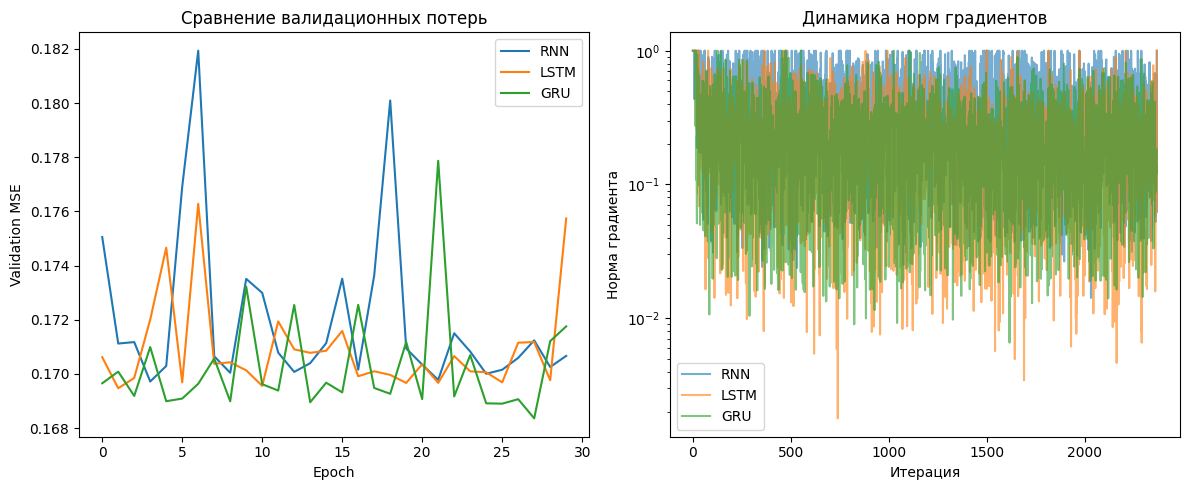

In [9]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(rnn_val_loss, label='RNN')
plt.plot(lstm_val_loss, label='LSTM')
plt.plot(gru_val_loss, label='GRU')
plt.xlabel('Epoch')
plt.ylabel('Validation MSE')
plt.legend()
plt.title('Сравнение валидационных потерь')

plt.subplot(1,2,2)
plt.plot(rnn_grads[:len(rnn_grads)], label='RNN', alpha=0.6)
plt.plot(lstm_grads[:len(lstm_grads)], label='LSTM', alpha=0.6)
plt.plot(gru_grads[:len(gru_grads)], label='GRU', alpha=0.6)
plt.xlabel('Итерация')
plt.ylabel('Норма градиента')
plt.yscale('log')
plt.legend()
plt.title('Динамика норм градиентов')
plt.tight_layout()
plt.show()

Теоретически надо было бы построить график такого плана:

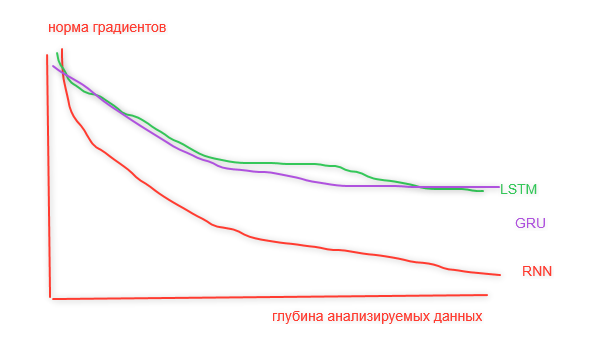

**Задание для интерпретации:**
1. Какая модель показала наименьшую ошибку на валидации? Почему, на ваш взгляд?
2. Посмотрите на график норм градиентов. Для какой модели градиенты быстрее всего уменьшаются? Связано ли это с проблемой затухания?
3. Попробуйте увеличить длину последовательности до 200 (сгенерируйте новые данные) и повторите обучение (измените `seq_len=200` в ячейке генерации). Что изменилось?

Ответы:
1. В целом, если смотреть не на самую последнюю эпоху, а не среднее последний эпох, то в таком случае GRU имеет наименьшил loss среди моделей.
2. Графики норм градиентов для всех моделей не имеют выраженного тренда на уменьшение, поэтому речи о затухаии градиентов быть не может.

Train shape: (5000, 200, 2), Val shape: (1000, 200, 2)
Training Vanilla RNN...
Epoch 5: train_loss=0.1688, val_loss=0.1879
Epoch 10: train_loss=0.1675, val_loss=0.1863
Epoch 15: train_loss=0.1663, val_loss=0.1833
Epoch 20: train_loss=0.1673, val_loss=0.1837
Epoch 25: train_loss=0.1668, val_loss=0.1859
Epoch 30: train_loss=0.1663, val_loss=0.1828

Training LSTM...
Epoch 5: train_loss=0.1674, val_loss=0.1825
Epoch 10: train_loss=0.1665, val_loss=0.1838
Epoch 15: train_loss=0.1664, val_loss=0.1826
Epoch 20: train_loss=0.1663, val_loss=0.1855
Epoch 25: train_loss=0.1669, val_loss=0.1831
Epoch 30: train_loss=0.1679, val_loss=0.1826

Training GRU...
Epoch 5: train_loss=0.1693, val_loss=0.1847
Epoch 10: train_loss=0.1660, val_loss=0.1823
Epoch 15: train_loss=0.1652, val_loss=0.1832
Epoch 20: train_loss=0.1666, val_loss=0.1823
Epoch 25: train_loss=0.1662, val_loss=0.1844
Epoch 30: train_loss=0.1668, val_loss=0.1824


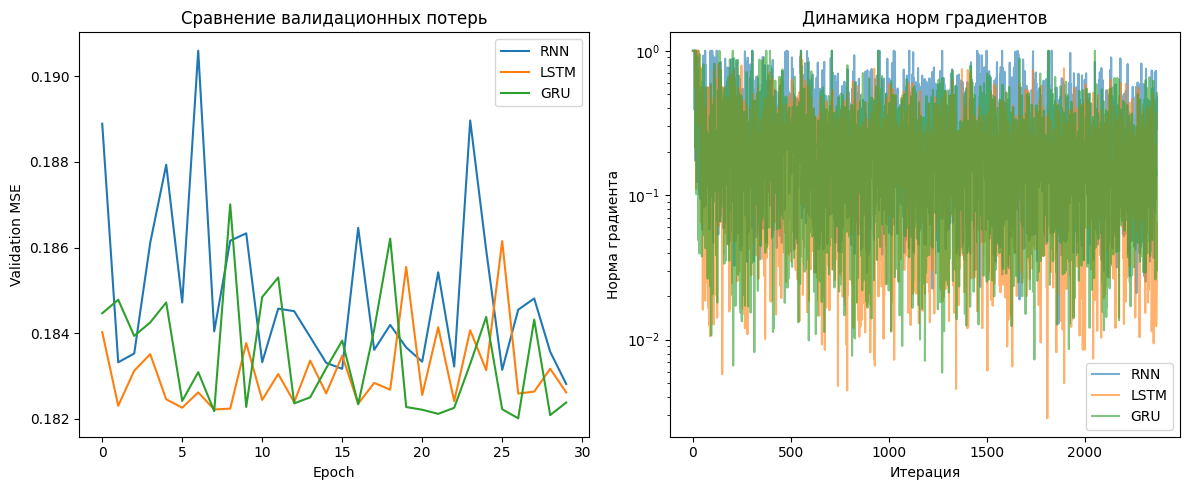

In [ ]:
seq_len = 200
train_X, train_y = generate_adding_problem_data(5000, seq_len)
val_X, val_y = generate_adding_problem_data(1000, seq_len)

print(f'Train shape: {train_X.shape}, Val shape: {val_X.shape}')

train_dataset = AddingDataset(train_X, train_y)
val_dataset = AddingDataset(val_X, val_y)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print("Training Vanilla RNN...")
rnn_model = VanillaRNN(input_size, hidden_size, output_size)
rnn_train_loss, rnn_val_loss, rnn_grads = train_model(rnn_model, train_loader, val_loader, epochs=epochs)

print("\nTraining LSTM...")
lstm_model = LSTMModel(input_size, hidden_size, output_size)
lstm_train_loss, lstm_val_loss, lstm_grads = train_model(lstm_model, train_loader, val_loader, epochs=epochs)

print("\nTraining GRU...")
gru_model = GRUModel(input_size, hidden_size, output_size)
gru_train_loss, gru_val_loss, gru_grads = train_model(gru_model, train_loader, val_loader, epochs=epochs)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(rnn_val_loss, label='RNN')
plt.plot(lstm_val_loss, label='LSTM')
plt.plot(gru_val_loss, label='GRU')
plt.xlabel('Epoch')
plt.ylabel('Validation MSE')
plt.legend()
plt.title('Сравнение валидационных потерь')

plt.subplot(1,2,2)
plt.plot(rnn_grads[:len(rnn_grads)], label='RNN', alpha=0.6)
plt.plot(lstm_grads[:len(lstm_grads)], label='LSTM', alpha=0.6)
plt.plot(gru_grads[:len(gru_grads)], label='GRU', alpha=0.6)
plt.xlabel('Итерация')
plt.ylabel('Норма градиента')
plt.yscale('log')
plt.legend()
plt.title('Динамика норм градиентов')
plt.tight_layout()
plt.show()

Ответы:

3. У всех моделей loss увеличился, нестабильность обучения осталась на том же уровне.

## **3. Эксперимент 2: Классификация тональности  комментариев на русском языке (RuSentiment)**

Используем датасет RuSentiment (отзывы о фильмах, размеченные по тональности: положительные, отрицательные, нейтральные).

**Задача:** обучить BiLSTM для классификации текста. Сравним однонаправленную LSTM и двунаправленную (BiLSTM), визуализируем скрытые состояния через t-SNE.

Labels meaning
0: NEUTRAL
1: POSITIVE
2: NEGATIVE

In [12]:
# Загружаем датасет с Hugging Face
dataset = load_dataset('Megnis/ru_sentiment_dataset-50000')
print(dataset)

# Посмотрим на распределение классов
from collections import Counter
labels = [ex['sentiment'] for ex in dataset['train']]
print(Counter(labels))

# Разделим на train, val, test (80/10/10) с помощью sklearn
from sklearn.model_selection import train_test_split

# Преобразуем Dataset в список для индексации
train_data = list(dataset['train'])
train_labels = [ex['sentiment'] for ex in train_data]

# Разделение: сначала 80% train, 20% temp
train_data_split, temp_data = train_test_split(
    train_data, test_size=0.2, random_state=42, stratify=train_labels
)

# Из temp делаем val и test (50/50 от 20% = 10% + 10%)
temp_labels = [ex['sentiment'] for ex in temp_data]
val_data, test_data = train_test_split(
    temp_data, test_size=0.5, random_state=42, stratify=temp_labels
)

print(f"Train size: {len(train_data_split)}, Val size: {len(val_data)}, Test size: {len(test_data)}")

README.md:   0%|          | 0.00/371 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/32.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/48212 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'text', 'sentiment'],
        num_rows: 48212
    })
})
Counter({2: 16158, 0: 16054, 1: 16000})
Train size: 38569, Val size: 4821, Test size: 4822


In [13]:
# Используем простой токенизатор на основе пробелов
def simple_tokenize(text, max_len=50):
    tokens = text.lower().split()[:max_len]
    return tokens

# Построим словарь по train_data
vocab = {'<PAD>': 0, '<UNK>': 1}
for example in train_data:
    for token in simple_tokenize(example['text']):
        if token not in vocab:
            vocab[token] = len(vocab)

vocab_size = len(vocab)
print(f'Vocabulary size: {vocab_size}')

Vocabulary size: 233935


In [14]:
def text_to_ids(text, max_len=50):
    tokens = simple_tokenize(text, max_len)
    ids = [vocab.get(token, 1) for token in tokens]
    if len(ids) < max_len:
        ids += [0] * (max_len - len(ids))
    return ids[:max_len]

class RuSentimentDataset(Dataset):
    def __init__(self, data_list, max_len=50):
        self.texts = [ex['text'] for ex in data_list]
        self.labels = [ex['sentiment'] for ex in data_list]
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = text_to_ids(self.texts[idx], self.max_len)
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

train_ds = RuSentimentDataset(train_data)
val_ds = RuSentimentDataset(val_data)
test_ds = RuSentimentDataset(test_data)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)
test_loader = DataLoader(test_ds, batch_size=64)

In [15]:
class LSTMSentiment(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, n_layers=1, bidirectional=False, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, n_layers, batch_first=True,
                            bidirectional=bidirectional, dropout=dropout)
        self.fc = nn.Linear(hidden_dim * (2 if bidirectional else 1), output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, _) = self.lstm(embedded)
        if self.lstm.bidirectional:
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden = hidden[-1,:,:]
        hidden = self.dropout(hidden)
        out = self.fc(hidden)
        return out

# Параметры
embed_dim = 100
hidden_dim = 128
output_dim = 3  # три класса: neutral, positive, negative

model_uni = LSTMSentiment(vocab_size, embed_dim, hidden_dim, output_dim, bidirectional=False).to(device)
model_bi = LSTMSentiment(vocab_size, embed_dim, hidden_dim, output_dim, bidirectional=True).to(device)

In [16]:
def train_sentiment(model, train_loader, val_loader, epochs=10, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        for X_batch, y_batch in pbar:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            pbar.set_postfix({'loss': loss.item()})
        train_losses.append(total_loss / len(train_loader))

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                pred = model(X_batch)
                _, predicted = torch.max(pred, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()
        val_acc = correct / total
        val_accs.append(val_acc)
        print(f'Epoch {epoch+1}: avg_train_loss={train_losses[-1]:.4f}, val_acc={val_acc:.4f}')

    return train_losses, val_accs

print("Training unidirectional LSTM...")
uni_loss, uni_acc = train_sentiment(model_uni, train_loader, val_loader, epochs=10)

print("\nTraining bidirectional LSTM...")
bi_loss, bi_acc = train_sentiment(model_bi, train_loader, val_loader, epochs=10)

Training unidirectional LSTM...


Epoch 1/10: 100%|██████████| 754/754 [00:08<00:00, 87.94it/s, loss=0.837]


Epoch 1: avg_train_loss=1.0453, val_acc=0.5360


Epoch 2/10: 100%|██████████| 754/754 [00:08<00:00, 87.53it/s, loss=0.884]


Epoch 2: avg_train_loss=0.9246, val_acc=0.6389


...

Epoch 8: avg_train_loss=0.0577, val_acc=0.9873


Epoch 9/10: 100%|██████████| 754/754 [00:06<00:00, 113.16it/s, loss=0.0837] 


Epoch 9: avg_train_loss=0.0479, val_acc=0.9907


Epoch 10/10: 100%|██████████| 754/754 [00:07<00:00, 106.29it/s, loss=0.00358]


Epoch 10: avg_train_loss=0.0397, val_acc=0.9898


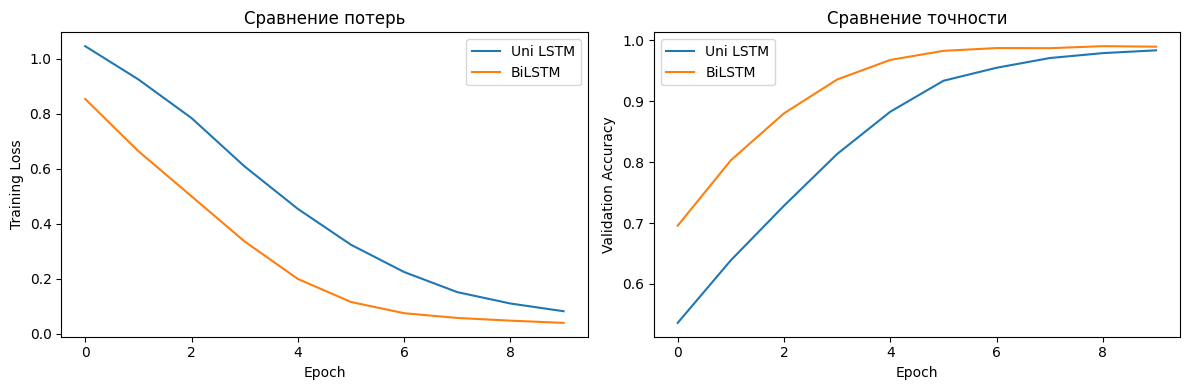

In [17]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(uni_loss, label='Uni LSTM')
plt.plot(bi_loss, label='BiLSTM')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend()
plt.title('Сравнение потерь')

plt.subplot(1,2,2)
plt.plot(uni_acc, label='Uni LSTM')
plt.plot(bi_acc, label='BiLSTM')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Сравнение точности')
plt.tight_layout()
plt.show()

### **3.1. Визуализация скрытых состояний с помощью t-SNE (3 класса)**

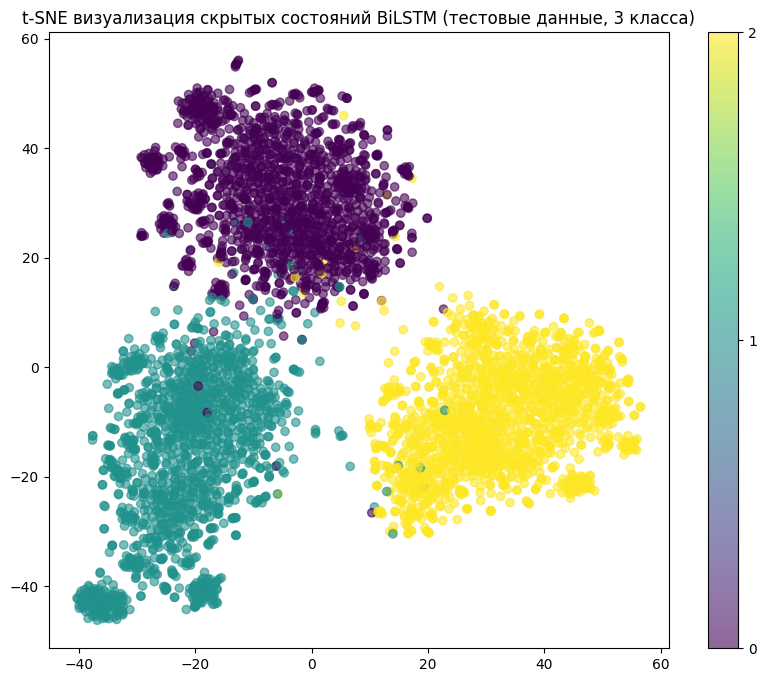

In [18]:
model_bi.eval()
hidden_states = []
labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        embedded = model_bi.embedding(X_batch)
        lstm_out, (hidden, _) = model_bi.lstm(embedded)
        if model_bi.lstm.bidirectional:
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden = hidden[-1,:,:]
        hidden_states.append(hidden.cpu().numpy())
        labels.append(y_batch.numpy())

hidden_states = np.vstack(hidden_states)
labels = np.hstack(labels)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
hidden_2d = tsne.fit_transform(hidden_states)

plt.figure(figsize=(10,8))
scatter = plt.scatter(hidden_2d[:,0], hidden_2d[:,1], c=labels, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, ticks=[0,1,2])
plt.title('t-SNE визуализация скрытых состояний BiLSTM (тестовые данные, 3 класса)')
plt.show()

**Задание для интерпретации:**
1. Сравните точность однонаправленной и двунаправленной LSTM. Какая модель оказалась лучше и почему?
2. Посмотрите на t-SNE проекцию. Видны ли кластеры, соответствующие разным классам? Если нет, то что это может означать? Можно ли как-то эту информацию использовать?
3. (Дополнительно) Попробуйте изменить размер скрытого состояния (`hidden_dim`) и количество слоёв LSTM (`n_layers`). Как это влияет на точность и время обучения?

Ответы:
1. Лучше оказалась двунаправленная LSTM, так как она видит весь контекст последовательности, в LSTM - только то, что было слева от текущей точки.
2. В t-SNE проекции очень четко видны кластеры разных классов. Это означает:

    2.1 У модели нет переобучения, предсказаниям модели можно верить

    2.2 Точки, которые попали не в свой кластер, можно дополнительно добавить в обучение с правильными метками класса.
    
    2.3 Такой рисунок можно показывать бизнесу, она хорошо показывает качество модели

Training unidirectional LSTM...


Epoch 1/10: 100%|██████████| 754/754 [00:12<00:00, 61.88it/s, loss=0.829]


Epoch 1: avg_train_loss=1.0588, val_acc=0.5294


Epoch 2/10: 100%|██████████| 754/754 [00:12<00:00, 62.36it/s, loss=0.841]


Epoch 2: avg_train_loss=0.8544, val_acc=0.6878


...

Epoch 8: avg_train_loss=0.0654, val_acc=0.9842


Epoch 9/10: 100%|██████████| 754/754 [00:20<00:00, 37.47it/s, loss=0.0215] 


Epoch 9: avg_train_loss=0.0509, val_acc=0.9900


Epoch 10/10: 100%|██████████| 754/754 [00:20<00:00, 37.68it/s, loss=0.00401]


Epoch 10: avg_train_loss=0.0408, val_acc=0.9859


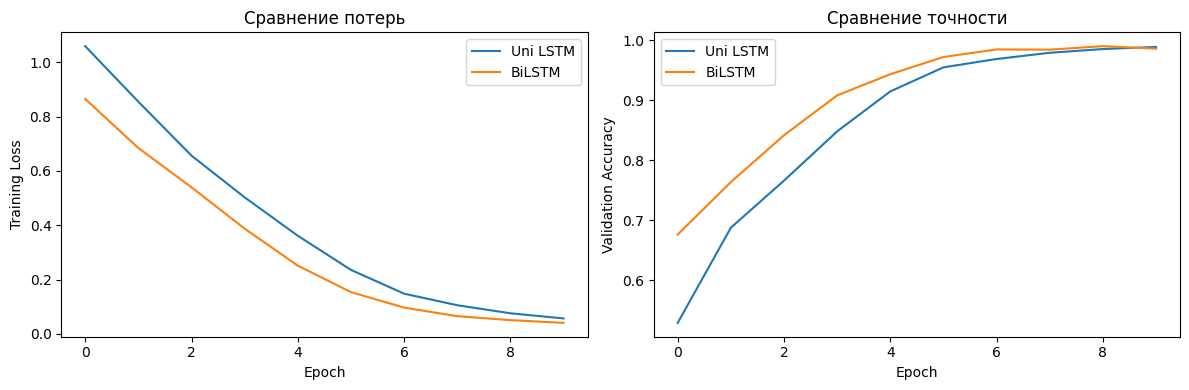

In [19]:
hidden_dim = 256

model_uni = LSTMSentiment(vocab_size, embed_dim, hidden_dim, output_dim, bidirectional=False, n_layers=3).to(device)
model_bi = LSTMSentiment(vocab_size, embed_dim, hidden_dim, output_dim, bidirectional=True,n_layers=3).to(device)

print("Training unidirectional LSTM...")
uni_loss, uni_acc = train_sentiment(model_uni, train_loader, val_loader, epochs=10)

print("\nTraining bidirectional LSTM...")
bi_loss, bi_acc = train_sentiment(model_bi, train_loader, val_loader, epochs=10)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(uni_loss, label='Uni LSTM')
plt.plot(bi_loss, label='BiLSTM')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.legend()
plt.title('Сравнение потерь')

plt.subplot(1,2,2)
plt.plot(uni_acc, label='Uni LSTM')
plt.plot(bi_acc, label='BiLSTM')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Сравнение точности')
plt.tight_layout()
plt.show()

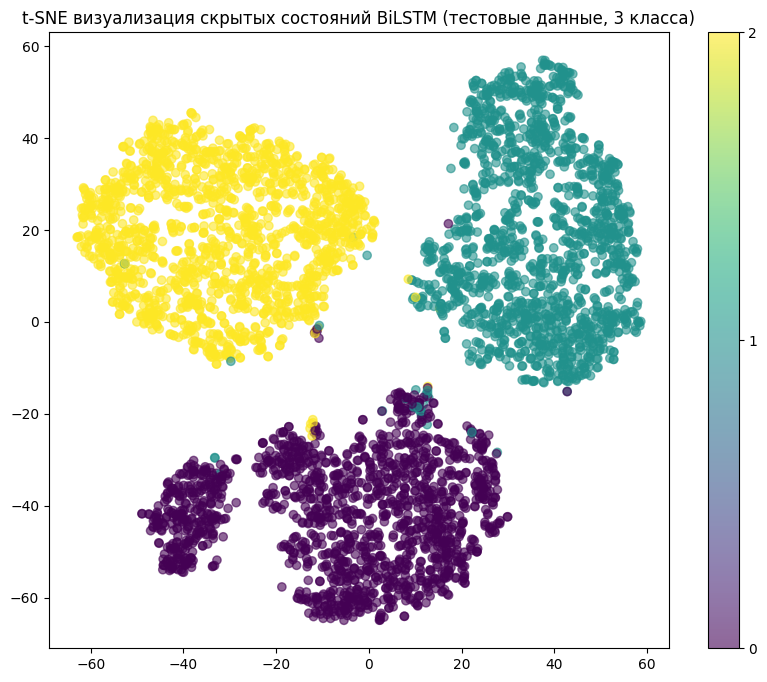

In [20]:
model_bi.eval()
hidden_states = []
labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        embedded = model_bi.embedding(X_batch)
        lstm_out, (hidden, _) = model_bi.lstm(embedded)
        if model_bi.lstm.bidirectional:
            hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            hidden = hidden[-1,:,:]
        hidden_states.append(hidden.cpu().numpy())
        labels.append(y_batch.numpy())

hidden_states = np.vstack(hidden_states)
labels = np.hstack(labels)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
hidden_2d = tsne.fit_transform(hidden_states)

plt.figure(figsize=(10,8))
scatter = plt.scatter(hidden_2d[:,0], hidden_2d[:,1], c=labels, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, ticks=[0,1,2])
plt.title('t-SNE визуализация скрытых состояний BiLSTM (тестовые данные, 3 класса)')
plt.show()

Ответы:

3. При hidden_dim=256 и n_layers=3 модель стала заметно дольше обучаться, но в то же время метрики тоже увеличились (правда не на очень много).

## **Заключение**

В этом практическом занятии мы:
- Убедились, что LSTM и GRU значительно лучше справляются с долгосрочными зависимостями, чем vanilla RNN.
- Визуализировали градиенты и увидели, что в RNN они быстро затухают.
- Применили BiLSTM для классификации русскоязычных текстов и сравнили с однонаправленной версией.
- Использовали t-SNE для визуализации скрытых представлений.

Попробуйте поэкспериментировать с гиперпараметрами и, возможно, применить предобученные эмбеддинги (FastText) для улучшения качества.

* Что нового узнали? Навыки/умения/знания.
* Обратная связь: что изменить по наполнению блокнотов материалам или способу подачи материала?